<a href="https://colab.research.google.com/github/AlifHammam/data-science-2026/blob/main/Pertemuan7_AlifHammamMultazam_240401010043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 7 - Pengantar Machine Learning: Regresi Linear

**Nama Lengkap:** Alif Hammam Multazam  
**NIM:** 240401010043  
**Kelas:** IF403

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Library berhasil diimport!')

Library berhasil diimport!


## Langkah 1 — Generate & Eksplorasi Dataset

In [2]:
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)  # 0=SMA, 1=D3, 2=S1
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu'       : edu,
    'kota'      : kota,
    'gaji'      : gaji
})

print('Shape:', df.shape)
print(df.describe().round(2))

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


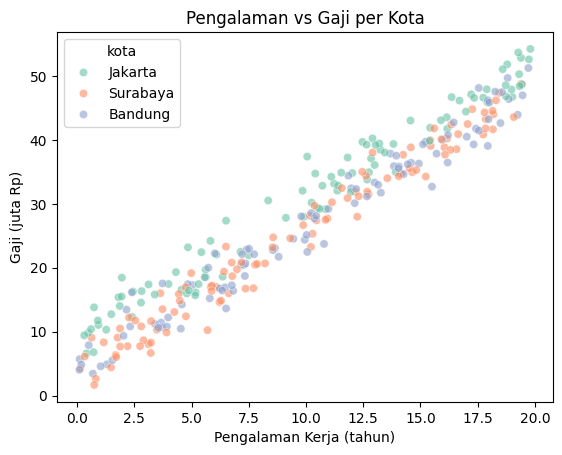

Rata-rata gaji per kota:
kota
Bandung     26.78
Jakarta     30.87
Surabaya    24.79
Name: gaji, dtype: float64


In [3]:
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman Kerja (tahun)')
plt.ylabel('Gaji (juta Rp)')
plt.show()

print('Rata-rata gaji per kota:')
print(df.groupby('kota')['gaji'].mean().round(2))

## Langkah 2 — Preprocessing

In [4]:
# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)

print('Kolom setelah encoding:', df.columns.tolist())
print(df.head())

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
   pengalaman  edu       gaji  kota_Jakarta  kota_Surabaya
0    7.490802    0  21.953247             1              0
1   19.014286    1  46.721665             1              0
2   14.639879    2  34.952649             0              1
3   11.973170    2  32.437143             0              0
4    3.120373    2  17.384265             1              0


In [5]:
X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')

Train: 240 baris
Test : 60 baris


In [6]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)  # hanya transform!

print('Mean scaler (dari train):', scaler.mean_.round(2))
print('Std scaler (dari train) :', scaler.scale_.round(2))

Mean scaler (dari train): [9.87 0.91 0.35 0.35]
Std scaler (dari train) : [5.93 0.84 0.48 0.48]


## Langkah 3 — Latih Model & Tampilkan Koefisien

In [7]:
model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')
print()

coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


## Langkah 4 — Evaluasi Model

In [8]:
y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


## Langkah 5 — Visualisasi & Interpretasi

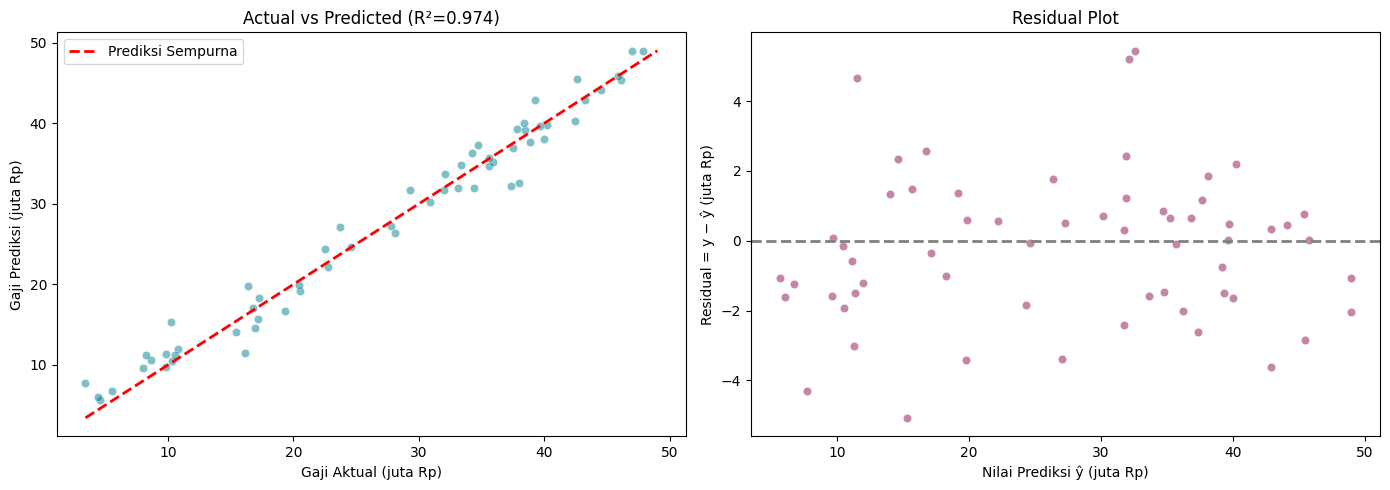

Mean residual : -0.2479  (idealnya mendekati 0)
Std  residual : 2.1262


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090',
                edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F',
                edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

print(f'Mean residual : {residuals.mean():.4f}  (idealnya mendekati 0)')
print(f'Std  residual : {residuals.std():.4f}')

### Interpretasi

Dari Actual vs Predicted terlihat titik-titik tersebar cukup dekat dengan garis merah putus-putus yang merepresentasikan prediksi sempurna, menunjukkan model cukup akurat. Pada Residual Plot, titik-titik tersebar secara acak di sekitar garis y=0 tanpa pola yang jelas, yang berarti asumsi linearitas terpenuhi dan model tidak mengalami masalah sistematis.

## Kesimpulan

Pada praktikum pertemuan ketujuh ini saya mempelajari konsep dasar Machine Learning, khususnya Regresi Linear sebagai algoritma regresi paling fundamental. Materi yang dipelajari meliputi perbedaan Supervised dan Unsupervised Learning, perbedaan tugas Classification dan Regression, serta cara kerja Regresi Linear secara matematis melalui persamaan ŷ = β₀ + β₁x₁ + ... + βₙxₙ beserta peran Cost Function MSE dan algoritma Ordinary Least Squares dalam menemukan koefisien optimal.

Melalui pipeline end-to-end pada dataset gaji sintetis, saya memahami cara mengaplikasikan One-Hot Encoding pada kolom kategorikal, melakukan Train-Test Split, menerapkan StandardScaler dengan benar hanya pada training set, lalu melatih model LinearRegression dari scikit-learn. Dari hasil evaluasi, model menunjukkan performa yang baik dengan R² yang tinggi, dan dari koefisien model terlihat bahwa pengalaman kerja dan lokasi Jakarta adalah dua faktor yang paling besar pengaruhnya terhadap prediksi gaji.

Keterbatasan pada praktikum ini adalah dataset yang digunakan merupakan data sintetis yang dihasilkan dari rumus deterministik, sehingga tidak sepenuhnya merepresentasikan kompleksitas data gaji di dunia nyata. Selain itu, Regresi Linear mengasumsikan hubungan yang bersifat linear antara fitur dan target, padahal hubungan di data nyata bisa jauh lebih kompleks. Meski demikian, praktikum ini sangat membantu dalam membangun fondasi pemahaman Machine Learning sebelum mempelajari algoritma yang lebih canggih.